# KrishokBot — Crop Disease YOLOv8m: Full Pipeline (Kaggle T4)

Single end-to-end notebook covering **all 12 steps** of `krishokbot_cv_pipeline.md`:
inspect → classes.txt → class maps → convert → split → merge → sanity-check →
`data.yaml` → train (2-stage) → eval (per-class) → export → `detector.py` wrapper.

**Before running:**
1. Add both Kaggle datasets as inputs to this notebook:
   - `nirmalsankalana/dhan-shomadhan`
   - `musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd`
2. Enable a **T4 GPU** accelerator (Settings → Accelerator).
3. Run cells **top to bottom, in order**. Two cells are marked
   `### MANUAL REVIEW REQUIRED` — you must open the generated JSON/report,
   confirm the actual class names on disk, and edit the cell below it
   before continuing. This mirrors the "sanity-check before trusting
   anything" discipline used throughout the project.

Outputs you'll walk away with, placed in `/kaggle/working/`:
- `crop_disease_best.pt` — deployment-ready YOLOv8m weights
- `eval_report.json` — overall + mandatory per-class mAP/precision/recall
- `detector.py` — confidence-tier inference wrapper for `krishokbot/vision/`
- `sanity_check_grid.jpg`, `stage1_loss_curves.png` — visual QA artifacts


In [1]:


# Kaggle already provides PyTorch, NumPy, OpenCV, and other
# core ML dependencies. Do NOT downgrade/reinstall NumPy here.

# Install only Ultralytics itself without modifying the
# existing Kaggle dependency stack.
!pip install -q --no-deps ultralytics==8.2.103

import ultralytics

print(f"Ultralytics version: {ultralytics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 35.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.2.103


In [2]:
import os
import json
import random
import shutil
import logging
from pathlib import Path
from collections import defaultdict

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
log = logging.getLogger("krishokbot")

WORK_DIR = Path("/kaggle/working")
DHAN_SHOMADHAN_ROOT = Path("/kaggle/input/datasets/nirmalsankalana/dhan-shomadhan")
BCDD_ROOT = Path("/kaggle/input/datasets/musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd")

# Verify the mounted paths actually exist before doing anything else.
# Kaggle sometimes nests an extra folder level — if this fails, run
# `import os; os.listdir('/kaggle/input')` and fix the paths above.
for name, p in [("Dhan-Shomadhan", DHAN_SHOMADHAN_ROOT), ("BCDD", BCDD_ROOT)]:
    if not p.exists():
        log.error("%s not found at %s — check /kaggle/input listing and fix the path above", name, p)
    else:
        log.info("%s OK: %s", name, p)


INFO: Dhan-Shomadhan OK: /kaggle/input/datasets/nirmalsankalana/dhan-shomadhan
INFO: BCDD OK: /kaggle/input/datasets/musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd


## Step 1 — Inspect raw dataset sources

Reports real folder/class names, image counts, corruption, and a best-effort annotation-format guess. **Do not assume** documentation matches what's actually on disk — this cell is the source of truth.

In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def inspect_folder_tree(root: Path) -> dict:
    from PIL import Image, UnidentifiedImageError
    report = {}
    corrupted = []
    for dirpath in sorted(root.rglob("*")):
        if not dirpath.is_dir():
            continue
        images = [p for p in dirpath.iterdir() if p.suffix.lower() in IMG_EXTS]
        if not images:
            continue
        resolutions = defaultdict(int)
        n_corrupt = 0
        for img_path in images:
            try:
                with Image.open(img_path) as im:
                    resolutions[str(im.size)] += 1
            except (UnidentifiedImageError, OSError):
                n_corrupt += 1
                corrupted.append(str(img_path))
        class_name = dirpath.relative_to(root).as_posix()
        report[class_name] = {
            "image_count": len(images),
            "corrupted_count": n_corrupt,
            "sample_resolutions": dict(list(resolutions.items())[:5]),
        }
    return {"classes": report, "corrupted_files": corrupted}


def detect_annotation_format(root: Path) -> str:
    has_txt_labels = any(root.rglob("*.txt"))
    has_class_subdirs = any(
        d.is_dir() and any(f.suffix.lower() in IMG_EXTS for f in d.iterdir())
        for d in root.rglob("*") if d.is_dir()
    )
    if has_txt_labels:
        return "possible_yolo_bbox"
    if has_class_subdirs:
        return "classification_folder_per_class"
    return "unknown"


inspection_report = {}
for name, path in [("dhan_shomadhan", DHAN_SHOMADHAN_ROOT), ("bcdd", BCDD_ROOT)]:
    if not path.exists():
        inspection_report[name] = {"error": f"path not found: {path}"}
        continue
    log.info("Inspecting %s ...", name)
    result = inspect_folder_tree(path)
    result["detected_format"] = detect_annotation_format(path)
    total_images = sum(c["image_count"] for c in result["classes"].values())
    total_corrupt = sum(c["corrupted_count"] for c in result["classes"].values())
    log.info("%s: %d classes/dirs, %d images, %d corrupted, format=%s",
              name, len(result["classes"]), total_images, total_corrupt, result["detected_format"])
    inspection_report[name] = result

(WORK_DIR / "inspection_report.json").write_text(json.dumps(inspection_report, indent=2, default=str), encoding="utf-8")
print(json.dumps({k: {"detected_format": v.get("detected_format"), "n_classes": len(v.get("classes", {}))}
                   for k, v in inspection_report.items()}, indent=2))


INFO: Inspecting dhan_shomadhan ...
INFO: dhan_shomadhan: 5 classes/dirs, 769 images, 0 corrupted, format=classification_folder_per_class
INFO: Inspecting bcdd ...
INFO: bcdd: 57 classes/dirs, 8992 images, 0 corrupted, format=classification_folder_per_class


{
  "dhan_shomadhan": {
    "detected_format": "classification_folder_per_class",
    "n_classes": 5
  },
  "bcdd": {
    "detected_format": "classification_folder_per_class",
    "n_classes": 57
  }
}


## Step 2 — `classes.txt` (unified class list)

### ⚠️ MANUAL REVIEW REQUIRED
Open the printed folder names above (or `/kaggle/working/inspection_report.json`)
and confirm they match the classes below **before running the next cell**.
Per `krishokbot_cv_pipeline.md` Step 2: *"do not assume class names match
across sources."* Edit `CLASSES` if the real folder names differ (e.g. BCDD
uses PlantVillage-style names like `Potato___Early_blight`, not
`potato_early_blight` — that mapping happens in Step 3's `class_map`, not here).


In [4]:
CLASSES = [
    "rice_brown_spot",
    "rice_leaf_scald",
    "rice_blast",
    "rice_tungro",
    "rice_bacterial_blight",
    "potato_early_blight",
    "potato_late_blight",
    "potato_healthy",
    "tomato_early_blight",
    "tomato_late_blight",
    "tomato_healthy",
]

classes_txt_path = WORK_DIR / "classes.txt"
classes_txt_path.write_text("\n".join(CLASSES) + "\n", encoding="utf-8")
CLASS_INDEX = {name: i for i, name in enumerate(CLASSES)}
print(f"{len(CLASSES)} classes written to {classes_txt_path}")
for i, c in enumerate(CLASSES):
    print(f"  {i}: {c}")


11 classes written to /kaggle/working/classes.txt
  0: rice_brown_spot
  1: rice_leaf_scald
  2: rice_blast
  3: rice_tungro
  4: rice_bacterial_blight
  5: potato_early_blight
  6: potato_late_blight
  7: potato_healthy
  8: tomato_early_blight
  9: tomato_late_blight
  10: tomato_healthy


## Step 3a — Class maps (source folder name → unified class name)

### ⚠️ MANUAL REVIEW REQUIRED
`DHAN_SHOMADHAN_CLASS_MAP` and `BCDD_CLASS_MAP` below are **templates** based
on the naming conventions documented for these datasets. Cross-check every
key against the actual folder names printed in Step 1's inspection report —
if a key doesn't match a real folder name exactly, that class is silently
dropped during conversion (the converters warn about unmapped folders, but
won't guess at typos). Edit before proceeding.


In [5]:
# BCDD (PlantVillage-origin) — potato + tomato classes only, per cv_pipeline.md scope.
BCDD_CLASS_MAP = {
    "Potato___Early_blight": "potato_early_blight",
    "Potato___Late_blight": "potato_late_blight",
    "Potato___healthy": "potato_healthy",
    "Tomato___Early_blight": "tomato_early_blight",
    "Tomato___Late_blight": "tomato_late_blight",
    "Tomato___healthy": "tomato_healthy",
}

# Dhan-Shomadhan — rice, field-collected. Folder names per dataset docs.
# NOTE: this dataset is classification-style (folder-per-class), same as BCDD,
# unless Step 1's detected_format says otherwise for this source — the next
# cell auto-branches on that.
DHAN_SHOMADHAN_CLASS_MAP = {
    "Rice___bacterial_blight": "rice_bacterial_blight",
    "Rice___blast": "rice_blast",
    "Rice___brown_spot": "rice_brown_spot",
    "Rice___leaf_scald": "rice_leaf_scald",
    "Rice___tungro": "rice_tungro",
}

(WORK_DIR / "bcdd_class_map.json").write_text(json.dumps(BCDD_CLASS_MAP, indent=2), encoding="utf-8")
(WORK_DIR / "dhan_shomadhan_class_map.json").write_text(json.dumps(DHAN_SHOMADHAN_CLASS_MAP, indent=2), encoding="utf-8")
print("Class maps written. Verify keys against inspection_report.json folder names.")


Class maps written. Verify keys against inspection_report.json folder names.


## Step 3b — Convert each source to YOLO format

Full-frame bounding box (`0.5 0.5 1.0 1.0`) is used for classification-style sources — a documented simplification (see `krishokbot_cv_pipeline.md`). If `inspection_report.json` shows `possible_yolo_bbox` for a source, real boxes exist and the remap path is used instead.

In [6]:
FULL_FRAME_BOX = "0.500000 0.500000 1.000000 1.000000"


def convert_classification_to_yolo(
    source_root: Path,
    class_map: dict,
    out_dir: Path,
    prefix: str
):
    """
    Convert classification-folder datasets into YOLO detection format.

    Each image gets one full-image bounding box:
        class_id 0.5 0.5 1.0 1.0

    Handles both:
      - flat class folders
      - nested class folders such as train/val/test/class_name

    Important:
      Multiple folders with the same class name are all processed.
      This avoids losing BCDD train/val/test data.
    """

    img_out = out_dir / "images"
    lbl_out = out_dir / "labels"

    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    converted = 0
    skipped_folders = []
    skipped_files = 0

    # ---------------------------------------------------------
    # Build lookup:
    #     folder name -> ALL matching directories
    #
    # Example:
    #   "Potato___Early_blight" ->
    #       [
    #           .../train/Potato___Early_blight,
    #           .../val/Potato___Early_blight,
    #           .../test/Potato___Early_blight
    #       ]
    # ---------------------------------------------------------
    folders_by_name = {}

    for d in source_root.rglob("*"):
        if d.is_dir():
            folders_by_name.setdefault(d.name, []).append(d)

    # ---------------------------------------------------------
    # Process every class mapping
    # ---------------------------------------------------------
    for folder_name, unified_class in class_map.items():

        folders = folders_by_name.get(folder_name, [])

        if not folders:
            skipped_folders.append(folder_name)
            continue

        # Validate unified class
        if unified_class not in CLASS_INDEX:
            raise ValueError(
                f"'{unified_class}' not in CLASSES / CLASS_INDEX. "
                f"Fix CLASSES or the class map."
            )

        class_id = CLASS_INDEX[unified_class]

        # -----------------------------------------------------
        # Process ALL matching folders
        # -----------------------------------------------------
        for folder in sorted(folders):

            # Include only actual image files
            image_files = sorted(
                p for p in folder.iterdir()
                if p.is_file() and p.suffix.lower() in IMG_EXTS
            )

            for i, img_path in enumerate(image_files):

                # -------------------------------------------------
                # Avoid filename collision.
                #
                # Example:
                #   bcdd_train_Potato___Early_blight_00000.jpg
                #   bcdd_val_Potato___Early_blight_00000.jpg
                #   bcdd_test_Potato___Early_blight_00000.jpg
                # -------------------------------------------------
                split_name = folder.parent.name

                new_name = (
                    f"{prefix}_{split_name}_{unified_class}_"
                    f"{i:05d}{img_path.suffix.lower()}"
                )

                shutil.copy2(
                    img_path,
                    img_out / new_name
                )

                # Full-image YOLO bounding box
                label_path = lbl_out / f"{Path(new_name).stem}.txt"

                label_path.write_text(
                    f"{class_id} {FULL_FRAME_BOX}\n",
                    encoding="utf-8"
                )

                converted += 1

            # Count non-image files
            total_files = sum(1 for p in folder.iterdir() if p.is_file())
            skipped_files += max(0, total_files - len(image_files))

    log.info(
        "[%s] converted=%d, unmatched_map_keys=%s, "
        "skipped_non_images=%d",
        prefix,
        converted,
        skipped_folders,
        skipped_files
    )

    return converted


def convert_bbox_remap(
    source_root: Path,
    class_map: dict,
    out_dir: Path,
    prefix: str
):
    """
    Convert an existing YOLO detection dataset while remapping
    source class IDs/names to the unified project classes.

    This function is kept for datasets that are already in
    YOLO bbox format.
    """

    img_out = out_dir / "images"
    lbl_out = out_dir / "labels"

    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # Locate images and labels directories
    # ---------------------------------------------------------
    images_dir = next(
        (d for d in source_root.rglob("images") if d.is_dir()),
        source_root
    )

    labels_dir = next(
        (d for d in source_root.rglob("labels") if d.is_dir()),
        source_root
    )

    converted = 0
    empty = 0

    image_files = sorted(
        p for p in images_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    )

    for i, img_path in enumerate(image_files):

        label_path = labels_dir / f"{img_path.stem}.txt"

        if not label_path.exists():
            empty += 1
            continue

        out_lines = []

        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines():

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            src_name, cx, cy, w, h = parts

            # Map source class -> unified class
            unified = class_map.get(src_name)

            if unified is None:
                continue

            if unified not in CLASS_INDEX:
                raise ValueError(
                    f"'{unified}' not in CLASSES / CLASS_INDEX."
                )

            out_lines.append(
                f"{CLASS_INDEX[unified]} {cx} {cy} {w} {h}"
            )

        # No valid labels after remapping
        if not out_lines:
            empty += 1
            continue

        new_stem = f"{prefix}_{i:06d}"

        new_image_path = img_out / (
            new_stem + img_path.suffix.lower()
        )

        new_label_path = lbl_out / f"{new_stem}.txt"

        shutil.copy2(
            img_path,
            new_image_path
        )

        new_label_path.write_text(
            "\n".join(out_lines) + "\n",
            encoding="utf-8"
        )

        converted += 1

    log.info(
        "[%s] bbox-remap converted=%d, empty_after_remap=%d",
        prefix,
        converted,
        empty
    )

    return converted


# =============================================================
# OUTPUT DIRECTORY
# =============================================================

converted_dir = WORK_DIR / "converted"


# =============================================================
# DATASET FORMAT
# =============================================================

bcdd_format = inspection_report.get(
    "bcdd",
    {}
).get(
    "detected_format",
    "classification_folder_per_class"
)

dhan_format = inspection_report.get(
    "dhan_shomadhan",
    {}
).get(
    "detected_format",
    "classification_folder_per_class"
)


# =============================================================
# BCDD CONVERSION
# =============================================================

log.info("Starting BCDD conversion...")

if bcdd_format == "possible_yolo_bbox":

    bcdd_converted = convert_bbox_remap(
        BCDD_ROOT,
        BCDD_CLASS_MAP,
        converted_dir / "bcdd",
        prefix="bcdd"
    )

else:

    bcdd_converted = convert_classification_to_yolo(
        BCDD_ROOT,
        BCDD_CLASS_MAP,
        converted_dir / "bcdd",
        prefix="bcdd"
    )

log.info(
    "BCDD conversion complete: %d images",
    bcdd_converted
)


# =============================================================
# DHAN-SHOMADHAN CONVERSION
# =============================================================

log.info("Starting Dhan-Shomadhan conversion...")

if dhan_format == "possible_yolo_bbox":

    dhan_converted = convert_bbox_remap(
        DHAN_SHOMADHAN_ROOT,
        DHAN_SHOMADHAN_CLASS_MAP,
        converted_dir / "dhan_shomadhan",
        prefix="dhanshomadhan"
    )

else:

    dhan_converted = convert_classification_to_yolo(
        DHAN_SHOMADHAN_ROOT,
        DHAN_SHOMADHAN_CLASS_MAP,
        converted_dir / "dhan_shomadhan",
        prefix="dhanshomadhan"
    )

log.info(
    "Dhan-Shomadhan conversion complete: %d images",
    dhan_converted
)


# =============================================================
# FINAL SUMMARY
# =============================================================

print("\n" + "=" * 60)
print("CONVERSION SUMMARY")
print("=" * 60)
print(f"BCDD converted           : {bcdd_converted}")
print(f"Dhan-Shomadhan converted : {dhan_converted}")
print(f"Total converted          : {bcdd_converted + dhan_converted}")
print("=" * 60)

INFO: Starting BCDD conversion...
INFO: [bcdd] converted=2880, unmatched_map_keys=[], skipped_non_images=0
INFO: BCDD conversion complete: 2880 images
INFO: Starting Dhan-Shomadhan conversion...
INFO: [dhanshomadhan] converted=769, unmatched_map_keys=[], skipped_non_images=0
INFO: Dhan-Shomadhan conversion complete: 769 images



CONVERSION SUMMARY
BCDD converted           : 2880
Dhan-Shomadhan converted : 769
Total converted          : 3649


## Step 5 — Split each converted source, per class, into train/val/test

Done **before** merging so no class or source is entirely absent from any split.

In [7]:
def get_primary_class_id(label_path: Path):
    lines = [l.strip() for l in label_path.read_text(encoding="utf-8").splitlines() if l.strip()]
    return int(lines[0].split()[0]) if lines else None


def split_dataset(converted_dir: Path, out_dir: Path, train=0.8, val=0.1, test=0.1, seed=42, min_per_split=1):
    assert abs(train + val + test - 1.0) < 1e-6
    random.seed(seed)
    img_dir, lbl_dir = converted_dir / "images", converted_dir / "labels"
    by_class = defaultdict(list)

    for label_path in sorted(lbl_dir.glob("*.txt")):
        img_candidates = list(img_dir.glob(label_path.stem + ".*"))
        if not img_candidates:
            continue
        cls_id = get_primary_class_id(label_path)
        if cls_id is None:
            continue
        by_class[cls_id].append((img_candidates[0], label_path))

    for split in ("train", "val", "test"):
        (out_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (out_dir / split / "labels").mkdir(parents=True, exist_ok=True)

    counts = defaultdict(lambda: defaultdict(int))
    for cls_id, pairs in by_class.items():
        cls_name = CLASSES[cls_id] if cls_id < len(CLASSES) else f"unknown_{cls_id}"
        random.shuffle(pairs)
        n = len(pairs)
        n_train, n_val = round(n * train), round(n * val)
        splits = {"train": pairs[:n_train], "val": pairs[n_train:n_train + n_val], "test": pairs[n_train + n_val:]}
        for split_name, split_pairs in splits.items():
            if len(split_pairs) < min_per_split:
                log.warning("Class '%s' has only %d images for split '%s' — under-represented, document in README",
                            cls_name, len(split_pairs), split_name)
            for img_path, lbl_path in split_pairs:
                shutil.copy2(img_path, out_dir / split_name / "images" / img_path.name)
                shutil.copy2(lbl_path, out_dir / split_name / "labels" / lbl_path.name)
            counts[cls_name][split_name] = len(split_pairs)
    return counts


split_dir = WORK_DIR / "split"
for source_name in ("bcdd", "dhan_shomadhan"):
    counts = split_dataset(converted_dir / source_name, split_dir / source_name)
    log.info("Split counts for %s:", source_name)
    for cls_name, c in counts.items():
        log.info("  %s: train=%d val=%d test=%d", cls_name, c.get("train", 0), c.get("val", 0), c.get("test", 0))


INFO: Split counts for bcdd:
INFO:   potato_early_blight: train=384 val=48 test=48
INFO:   potato_healthy: train=384 val=48 test=48
INFO:   potato_late_blight: train=384 val=48 test=48
INFO:   tomato_early_blight: train=384 val=48 test=48
INFO:   tomato_healthy: train=384 val=48 test=48
INFO:   tomato_late_blight: train=384 val=48 test=48
INFO: Split counts for dhan_shomadhan:
INFO:   rice_bacterial_blight: train=175 val=22 test=22
INFO:   rice_blast: train=158 val=20 test=20
INFO:   rice_brown_spot: train=72 val=9 test=9
INFO:   rice_leaf_scald: train=114 val=14 test=15
INFO:   rice_tungro: train=95 val=12 test=12


## Step 4 — Merge sources into the final dataset

Filenames are already source-prefixed (collision-safe). Fails loudly on real collisions instead of silently overwriting.

In [8]:
def merge_datasets(source_dirs, out_dir: Path):
    total_copied, collisions = 0, []
    for split in ("train", "val", "test"):
        img_out, lbl_out = out_dir / split / "images", out_dir / split / "labels"
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)
        for source in source_dirs:
            src_img_dir = source / split / "images"
            src_lbl_dir = source / split / "labels"
            if not src_img_dir.exists():
                continue
            for img_path in sorted(src_img_dir.iterdir()):
                dest = img_out / img_path.name
                if dest.exists():
                    collisions.append(str(dest))
                    continue
                shutil.copy2(img_path, dest)
                lbl_path = src_lbl_dir / (img_path.stem + ".txt")
                if lbl_path.exists():
                    shutil.copy2(lbl_path, lbl_out / lbl_path.name)
                total_copied += 1
    if collisions:
        raise RuntimeError(f"{len(collisions)} filename collisions detected: {collisions[:5]}")
    return total_copied


MERGED_DIR = WORK_DIR / "dataset_crop_disease_yolo"
n = merge_datasets([split_dir / "bcdd", split_dir / "dhan_shomadhan"], MERGED_DIR)
log.info("Merged %d images into %s", n, MERGED_DIR)
for split in ("train", "val", "test"):
    log.info("  %s: %d images", split, len(list((MERGED_DIR / split / "images").iterdir())))


INFO: Merged 3649 images into /kaggle/working/dataset_crop_disease_yolo
INFO:   train: 2918 images
INFO:   val: 365 images
INFO:   test: 366 images


## Step 6 — Sanity-check the merged dataset BEFORE training

Draws boxes on a sample grid per class. **Visually inspect the saved grid image below before proceeding to training** — catching a labeling bug here costs seconds; catching it after a T4 training run costs hours.

INFO: Grid saved to /kaggle/working/sanity_check_grid.jpg. Classes represented: 11/11. Missing: []


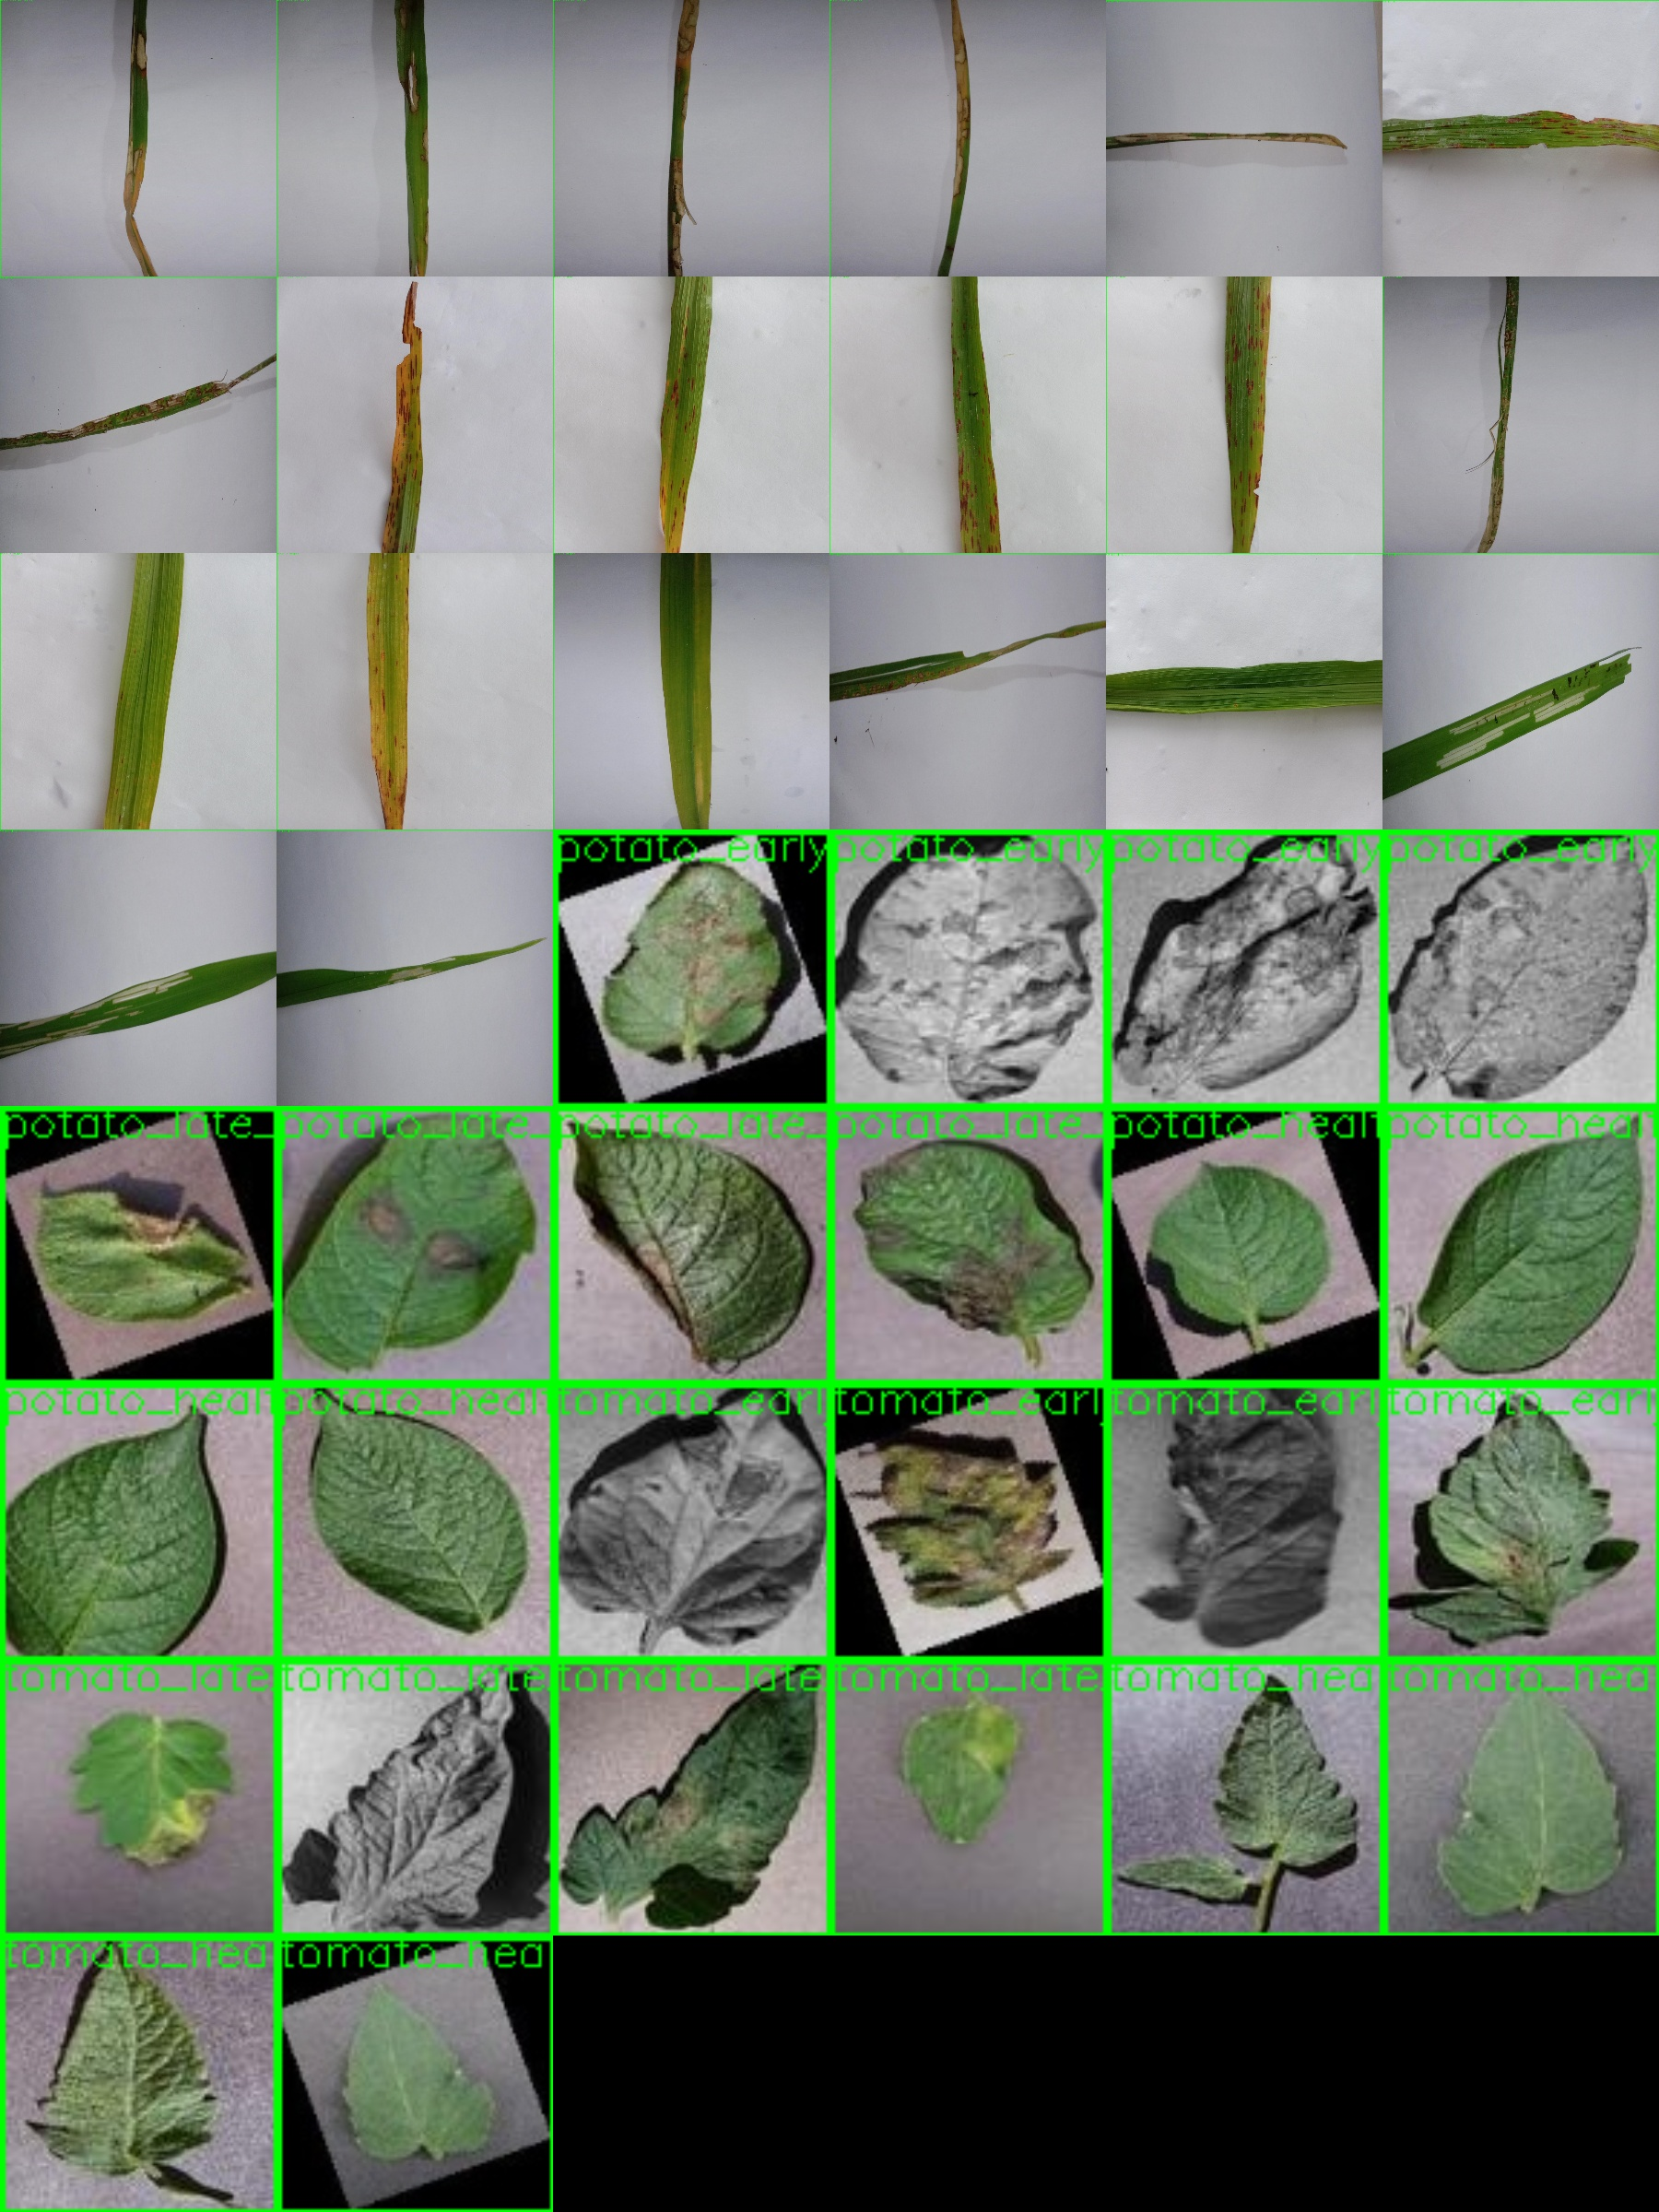

In [9]:
import cv2

def validate_label_line(line: str, n_classes: int):
    parts = line.split()
    if len(parts) != 5:
        return False, f"expected 5 fields, got {len(parts)}"
    try:
        cls_id = int(parts[0]); cx, cy, w, h = map(float, parts[1:])
    except ValueError:
        return False, "non-numeric field"
    if not (0 <= cls_id < n_classes):
        return False, f"class id {cls_id} out of range"
    if not all(0.0 <= v <= 1.0 for v in (cx, cy, w, h)):
        return False, "coords out of [0,1]"
    return True, ""


def draw_boxes(img_path: Path, label_path: Path, class_names):
    img = cv2.imread(str(img_path))
    if img is None:
        return None, [f"failed to load {img_path}"]
    h, w = img.shape[:2]
    errors = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        ok, msg = validate_label_line(line, len(class_names))
        if not ok:
            errors.append(f"{label_path.name}: {msg}")
            continue
        cls_id, cx, cy, bw, bh = line.split()
        cls_id, cx, cy, bw, bh = int(cls_id), float(cx), float(cy), float(bw), float(bh)
        x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
        x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, class_names[cls_id], (x1, max(y1 - 5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return img, errors


def sanity_check(dataset_dir: Path, class_names, split="train", samples_per_class=4, seed=42, out_path=None):
    random.seed(seed)
    img_dir, lbl_dir = dataset_dir / split / "images", dataset_dir / split / "labels"
    by_class, all_errors, missing = defaultdict(list), [], 0

    for img_path in sorted(img_dir.iterdir()):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            missing += 1
            continue
        lines = lbl_path.read_text(encoding="utf-8").splitlines()
        if not lines:
            continue
        try:
            cls_id = int(lines[0].split()[0])
        except (ValueError, IndexError):
            continue
        by_class[cls_id].append((img_path, lbl_path))

    if missing:
        log.error("%d images in %s have NO label file", missing, split)

    tiles = []
    for cls_id, pairs in sorted(by_class.items()):
        for img_path, lbl_path in random.sample(pairs, min(samples_per_class, len(pairs))):
            annotated, errors = draw_boxes(img_path, lbl_path, class_names)
            all_errors.extend(errors)
            if annotated is not None:
                tiles.append(cv2.resize(annotated, (300, 300)))

    if all_errors:
        log.error("Found %d malformed labels (first 10): %s", len(all_errors), all_errors[:10])
    if not tiles:
        log.error("No valid samples found")
        return None

    cols = 6
    rows = (len(tiles) + cols - 1) // cols
    grid = None
    for r in range(rows):
        row_tiles = tiles[r * cols:(r + 1) * cols]
        while len(row_tiles) < cols:
            row_tiles.append(0 * row_tiles[0])
        row_img = cv2.hconcat(row_tiles)
        grid = row_img if grid is None else cv2.vconcat([grid, row_img])

    out_path = out_path or (WORK_DIR / "sanity_check_grid.jpg")
    cv2.imwrite(str(out_path), grid)
    missing_classes = [c for i, c in enumerate(class_names) if i not in by_class]
    log.info("Grid saved to %s. Classes represented: %d/%d. Missing: %s",
              out_path, len(by_class), len(class_names), missing_classes)
    return out_path


grid_path = sanity_check(MERGED_DIR, CLASSES, split="train")
if grid_path:
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=str(grid_path)))


### ⚠️ STOP AND LOOK
Open the grid image above. Confirm boxes and class labels look correct, and that no class shows systematically wrong crops/labels, before running the training cells below.

## `data.yaml` generation

(Fills the gap `train_yolo_kaggle.py` assumed was already done — this is what was previously missing as `generate_data_yaml.py`.)

In [10]:
import yaml as pyyaml

data_yaml_path = WORK_DIR / "data.yaml"
data_yaml = {
    "path": str(MERGED_DIR),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": len(CLASSES),
    "names": {i: name for i, name in enumerate(CLASSES)},
}
with open(data_yaml_path, "w", encoding="utf-8") as f:
    pyyaml.dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print(data_yaml_path.read_text())
assert data_yaml_path.exists()


path: /kaggle/working/dataset_crop_disease_yolo
train: train/images
val: val/images
test: test/images
nc: 11
names:
  0: rice_brown_spot
  1: rice_leaf_scald
  2: rice_blast
  3: rice_tungro
  4: rice_bacterial_blight
  5: potato_early_blight
  6: potato_late_blight
  7: potato_healthy
  8: tomato_early_blight
  9: tomato_late_blight
  10: tomato_healthy



In [11]:
import sys
import subprocess

subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "ray", "ray-core"],
    check=False
)

print("Ray removed.")

Found existing installation: ray 2.55.1
Uninstalling ray-2.55.1:
  Successfully uninstalled ray-2.55.1
Ray removed.


In [12]:
import os

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

print("W&B disabled.")

W&B disabled.


## Step 8 — Train YOLOv8m, two-stage (T4)

**Stage 1** — general training, ~40 epochs, augmentation on, full training set.

In [13]:
from ultralytics import YOLO

DATA_YAML = str(WORK_DIR / "data.yaml")

model = YOLO("yolov8m.pt")

stage1_results = model.train(
    data=DATA_YAML,
    epochs=40,
    imgsz=640,
    batch=16,
    device=0,
    project="runs",
    name="stage1_general",
    augment=True,
    mosaic=1.0,
    patience=15,
    verbose=True,
)

100%|██████████| 49.7M/49.7M [00:00<00:00, 329MB/s]


New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/kaggle/working/data.yaml, epochs=40, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=runs, name=stage1_general, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, s

100%|██████████| 755k/755k [00:00<00:00, 111MB/s]


Overriding model.yaml nc=80 with nc=11

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytic

100%|██████████| 6.25M/6.25M [00:00<00:00, 262MB/s]


...

      40/40         7G    0.02227     0.1425     0.8857          6        640: 100%|██████████| 183/183 [01:51<00:00,  1.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:05<00:00,  2.26it/s]

                   all        365        365      0.826      0.906      0.922      0.922



40 epochs completed in 1.317 hours.
Optimizer stripped from runs/stage1_general/weights/last.pt, 52.0MB
Optimizer stripped from runs/stage1_general/weights/best.pt, 52.0MB

Validating runs/stage1_general/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 218 layers, 25,846,129 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:11<00:00,  1.03it/s]


                   all        365        365      0.804      0.917      0.926      0.926
       rice_brown_spot          9          9      0.429      0.889      0.862      0.862
       rice_leaf_scald         14         14      0.746      0.631      0.718      0.718
            rice_blast         20         20      0.693      0.905      0.857      0.857
           rice_tungro         12         12      0.698      0.833      0.841      0.841
 rice_bacterial_blight         22         22      0.845      0.989      0.989      0.989
   potato_early_blight         48         48          1      0.997      0.995      0.995
    potato_late_blight         48         48       0.76      0.979      0.979      0.979
        potato_healthy         48         48      0.917      0.979       0.99       0.99
   tomato_early_blight         48         48          1      0.913      0.984      0.984
    tomato_late_blight         48         48      0.817      0.979      0.985      0.985
        tomato_health

### Sanity-check Stage 1 loss curves BEFORE proceeding to Stage 2
Val loss climbing while train loss keeps dropping = overfitting — stop and investigate rather than proceeding blindly.

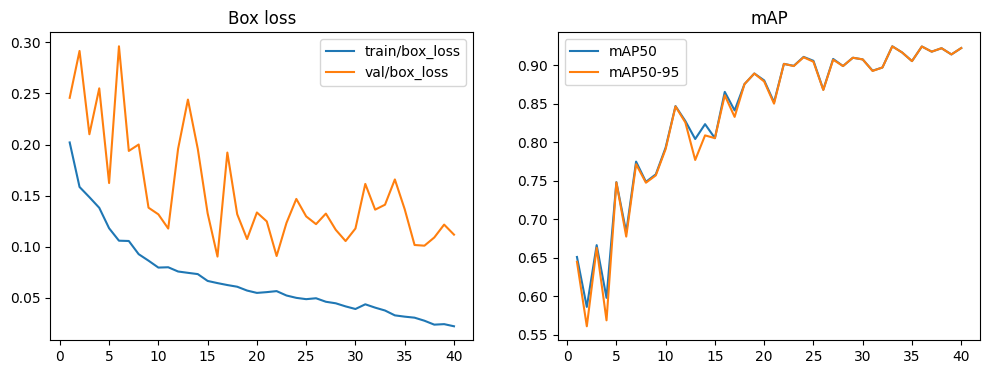

    epoch  train/box_loss  val/box_loss  metrics/mAP50(B)  metrics/mAP50-95(B)
35     36         0.03068       0.10176           0.92402              0.92402
36     37         0.02771       0.10109           0.91734              0.91734
37     38         0.02386       0.10910           0.92181              0.92181
38     39         0.02436       0.12171           0.91373              0.91373
39     40         0.02227       0.11189           0.92204              0.92204


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

results_csv = WORK_DIR / "runs" / "stage1_general" / "results.csv"
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
ax[0].plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
ax[0].legend(); ax[0].set_title("Box loss")
ax[1].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
ax[1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
ax[1].legend(); ax[1].set_title("mAP")
plt.savefig(WORK_DIR / "stage1_loss_curves.png")
plt.show()

print(df[["epoch", "train/box_loss", "val/box_loss", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]].tail(5))


**Stage 2** — adaptive fine-tune, ~10 epochs, lower LR, augmentation off. If Step 6's sanity check flagged bad samples that you manually removed from `MERGED_DIR`, this automatically fine-tunes on the cleaned data since `data.yaml` points at the same directory.

In [15]:
stage1_best = Path("runs/stage1_general/weights/best.pt")
assert stage1_best.exists(), "Stage 1 best.pt not found — Stage 1 did not complete successfully"

model_stage2 = YOLO(str(stage1_best))

stage2_results = model_stage2.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    project="runs",
    name="stage2_finetune",
    augment=False,
    mosaic=0.0,
    lr0=0.001,
    patience=5,
    verbose=True,
)


New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: task=detect, mode=train, model=runs/stage1_general/weights/best.pt, data=/kaggle/working/data.yaml, epochs=10, time=None, patience=5, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=runs, name=stage2_finetune, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False,

train: Scanning /kaggle/working/dataset_crop_disease_yolo/train/labels.cache... 2918 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2918/2918 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1837: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /kaggle/working/dataset_crop_disease_yolo/val/labels.cache... 365 images, 0 backgrounds, 0 corrupt: 100%|██████████| 365/365 [00:00<?, ?it/s]


Plotting labels to runs/stage2_finetune/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000667, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to runs/stage2_finetune
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

       6/10      7.63G      0.049     0.3327       0.89          6        640: 100%|██████████| 183/183 [01:51<00:00,  1.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:05<00:00,  2.28it/s]

                   all        365        365      0.816      0.856      0.882      0.882
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 1, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



6 epochs completed in 0.199 hours.
Optimizer stripped from runs/stage2_finetune/weights/last.pt, 52.0MB
Optimizer stripped from runs/stage2_finetune/weights/best.pt, 52.0MB

Validating runs/stage2_finetune/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 218 layers, 25,846,129 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:05<00:00,  2.13it/s]


                   all        365        365      0.797      0.855      0.886      0.886
       rice_brown_spot          9          9      0.808      0.667      0.747      0.747
       rice_leaf_scald         14         14      0.373      0.594      0.526      0.526
            rice_blast         20         20      0.726      0.795      0.888      0.888
           rice_tungro         12         12       0.64      0.741      0.784      0.784
 rice_bacterial_blight         22         22      0.896      0.864      0.937      0.937
   potato_early_blight         48         48      0.972      0.958      0.993      0.993
    potato_late_blight         48         48      0.744          1      0.944      0.944
        potato_healthy         48         48          1      0.913      0.988      0.988
   tomato_early_blight         48         48        0.8      0.979      0.986      0.986
    tomato_late_blight         48         48      0.845      0.938       0.96       0.96
        tomato_health

## Step 9 — Evaluate on held-out TEST set (mandatory per-class breakdown)

Any class with AP50 < 0.6 is flagged — documented as a limitation, never hidden in the aggregate.

In [16]:
best_final = Path("runs/stage2_finetune/weights/best.pt")
eval_model = YOLO(str(best_final))

metrics = eval_model.val(data=DATA_YAML, split="test", save_json=True)

overall = {
    "mAP50": float(metrics.box.map50),
    "mAP50-95": float(metrics.box.map),
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
}
print("OVERALL:", overall)

class_names = eval_model.names
per_class = {}
for i, cls_name in class_names.items():
    per_class[cls_name] = {
        "precision": float(metrics.box.p[i]) if i < len(metrics.box.p) else None,
        "recall": float(metrics.box.r[i]) if i < len(metrics.box.r) else None,
        "ap50": float(metrics.box.ap50[i]) if i < len(metrics.box.ap50) else None,
    }
    if per_class[cls_name]["ap50"] is not None and per_class[cls_name]["ap50"] < 0.6:
        print(f"WARNING: {cls_name} AP50={per_class[cls_name]['ap50']:.3f} < 0.6 — "
              f"flag as a documented limitation in the README")

eval_report = {"overall": overall, "per_class": per_class}
(WORK_DIR / "eval_report.json").write_text(json.dumps(eval_report, indent=2))
print(json.dumps(eval_report, indent=2))


Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 218 layers, 25,846,129 parameters, 0 gradients


val: Scanning /kaggle/working/dataset_crop_disease_yolo/test/labels... 366 images, 0 backgrounds, 0 corrupt: 100%|██████████| 366/366 [00:00<00:00, 1226.45it/s]


val: New cache created: /kaggle/working/dataset_crop_disease_yolo/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 23/23 [00:11<00:00,  2.04it/s]


                   all        366        366      0.871      0.921      0.946      0.946
       rice_brown_spot          9          9      0.872       0.76      0.854      0.854
       rice_leaf_scald         15         15       0.66        0.8      0.803      0.803
            rice_blast         20         20      0.715        0.9      0.897      0.897
           rice_tungro         12         12      0.916      0.904      0.958      0.958
 rice_bacterial_blight         22         22          1       0.98      0.995      0.995
   potato_early_blight         48         48      0.971          1      0.995      0.995
    potato_late_blight         48         48      0.811      0.979      0.971      0.971
        potato_healthy         48         48       0.99      0.958      0.991      0.991
   tomato_early_blight         48         48      0.849      0.979      0.988      0.988
    tomato_late_blight         48         48      0.841      0.938      0.958      0.958
        tomato_health

## Step 11 — Export deployment-ready model + standalone load check

Simulates a clean load exactly as `vision/detector.py` will do it, with no dependency on training state.

In [17]:
shutil.copy2(best_final, WORK_DIR / "crop_disease_best.pt")

fresh_model = YOLO(str(WORK_DIR / "crop_disease_best.pt"))
import numpy as np
dummy_image = np.zeros((640, 640, 3), dtype=np.uint8)
result = fresh_model.predict(dummy_image, verbose=False)
print("Standalone load + inference check: OK" if result is not None else "FAILED")
print("Model classes:", fresh_model.names)


Standalone load + inference check: OK
Model classes: {0: 'rice_brown_spot', 1: 'rice_leaf_scald', 2: 'rice_blast', 3: 'rice_tungro', 4: 'rice_bacterial_blight', 5: 'potato_early_blight', 6: 'potato_late_blight', 7: 'potato_healthy', 8: 'tomato_early_blight', 9: 'tomato_late_blight', 10: 'tomato_healthy'}


## Step 12 — `vision/detector.py` wrapper (confidence-tier logic)

Same visual language as the BD License Plate Detector project: green ≥0.85 / amber 0.60–0.85 / red <0.60. Loads `crop_disease_best.pt`, runs inference, returns tiered detections. Also appends red-tier detections to `eval/results/pending_review.jsonl` per `krishokbot_addendum_plan.md` Section 5 (escalation-queue hook, not an active reviewer).

In [18]:
detector_py = '''"""
vision/detector.py — KrishokBot crop-disease YOLO inference wrapper.

Mirrors the confidence-tier pattern used in the BD License Plate Detector:
    green  >= 0.85   high confidence
    amber  0.60-0.85 medium confidence
    red    <  0.60   low confidence -> logged to eval/results/pending_review.jsonl
                      as an escalation-queue hook (no active human reviewer in
                      this version -- see krishokbot_addendum_plan.md Section 5).
"""
import json
import time
from pathlib import Path

from ultralytics import YOLO

WEIGHTS_PATH = Path(__file__).parent / "weights" / "crop_disease_best.pt"
PENDING_REVIEW_PATH = Path(__file__).parent.parent / "eval" / "results" / "pending_review.jsonl"

GREEN_THRESHOLD = 0.85
AMBER_THRESHOLD = 0.60


def _tier(confidence: float) -> str:
    if confidence >= GREEN_THRESHOLD:
        return "green"
    if confidence >= AMBER_THRESHOLD:
        return "amber"
    return "red"


class CropDiseaseDetector:
    def __init__(self, weights_path: Path = WEIGHTS_PATH):
        if not weights_path.exists():
            raise FileNotFoundError(
                f"{weights_path} not found -- place crop_disease_best.pt "
                f"in vision/weights/ before using this detector."
            )
        self.model = YOLO(str(weights_path))

    def predict(self, image, image_ref: str = "unknown", log_low_confidence: bool = True):
        """
        image: path, PIL Image, or numpy array (anything ultralytics.YOLO.predict accepts)
        image_ref: identifier for the image, used only in the pending-review log

        Returns a list of dicts:
            {"class_name": str, "confidence": float, "tier": "green"|"amber"|"red", "bbox": [x1,y1,x2,y2]}
        """
        results = self.model.predict(image, verbose=False)
        detections = []
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                confidence = float(box.conf[0])
                detections.append({
                    "class_name": self.model.names[cls_id],
                    "confidence": confidence,
                    "tier": _tier(confidence),
                    "bbox": [float(v) for v in box.xyxy[0].tolist()],
                })

        if log_low_confidence:
            for det in detections:
                if det["tier"] == "red":
                    self._log_pending_review(image_ref, det)

        return detections

    def _log_pending_review(self, image_ref: str, detection: dict):
        PENDING_REVIEW_PATH.parent.mkdir(parents=True, exist_ok=True)
        entry = {
            "timestamp": time.time(),
            "input_type": "image",
            "image_ref": image_ref,
            "model_output": detection,
            "confidence": detection["confidence"],
            "reason_flagged": "red_tier_confidence_below_0.60",
        }
        with open(PENDING_REVIEW_PATH, "a", encoding="utf-8") as f:
            f.write(json.dumps(entry, ensure_ascii=False) + "\\n")


if __name__ == "__main__":
    import sys
    detector = CropDiseaseDetector()
    image_path = sys.argv[1] if len(sys.argv) > 1 else None
    if image_path:
        for det in detector.predict(image_path, image_ref=image_path):
            print(det)
'''

detector_out = WORK_DIR / "detector.py"
detector_out.write_text(detector_py, encoding="utf-8")
print(f"Written to {detector_out}")
print("Place this at krishokbot/vision/detector.py, alongside vision/weights/crop_disease_best.pt")


Written to /kaggle/working/detector.py
Place this at krishokbot/vision/detector.py, alongside vision/weights/crop_disease_best.pt


## Done — download these from `/kaggle/working/`

| File | Destination in `krishokbot/` |
|---|---|
| `crop_disease_best.pt` | `vision/weights/crop_disease_best.pt` |
| `detector.py` | `vision/detector.py` |
| `eval_report.json` | `eval/results/vision_eval_report.json` — use these **real** numbers in the README, never hand-typed placeholders |
| `classes.txt`, `bcdd_class_map.json`, `dhan_shomadhan_class_map.json` | keep in `rag/data/` or project root as a record of the exact scope used |
| `sanity_check_grid.jpg`, `stage1_loss_curves.png` | optional — useful evidence for the README's methodology section |

**Not automated by this notebook (per `krishokbot_cv_pipeline.md`, inherently manual):**
- Step 7 — uploading the merged dataset to Kaggle as a new dataset (only needed if you want to persist `dataset_crop_disease_yolo/` across sessions instead of rebuilding it each run)
- Step 10 — qualitative check on real, unseen web images outside both source datasets

Wiring `vision/detector.py` into the main LangGraph agent (`agent/graph.py`) is the next step, per `krishokbot_project_plan.md` Section 7, Step 9.
